In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("../../data/noisy_reversal.csv")
df.head(5)

,Unnamed: 0,review,model,sentiment
0,0,ehT eivom saw a etelpmoc .tsefezoons I detterg...,Gemini-1.5-Flash,negative
1,1,",ylsuoireS eht tsrow eunev ev'I reve neeb .ot ...",Gemini-1.5-Flash,negative
2,2,"sihT tneve saw os ylroop ,dezinagro ti saw a ....",Gemini-1.5-Flash,negative
3,3,"tahW a retsasid fo a !eivom ehT gnitca saw ,lu...",Gemini-1.5-Flash,negative
4,4,I t'ndluow dnemmocer siht eunev ot ym tsrow .y...,Gemini-1.5-Flash,negative


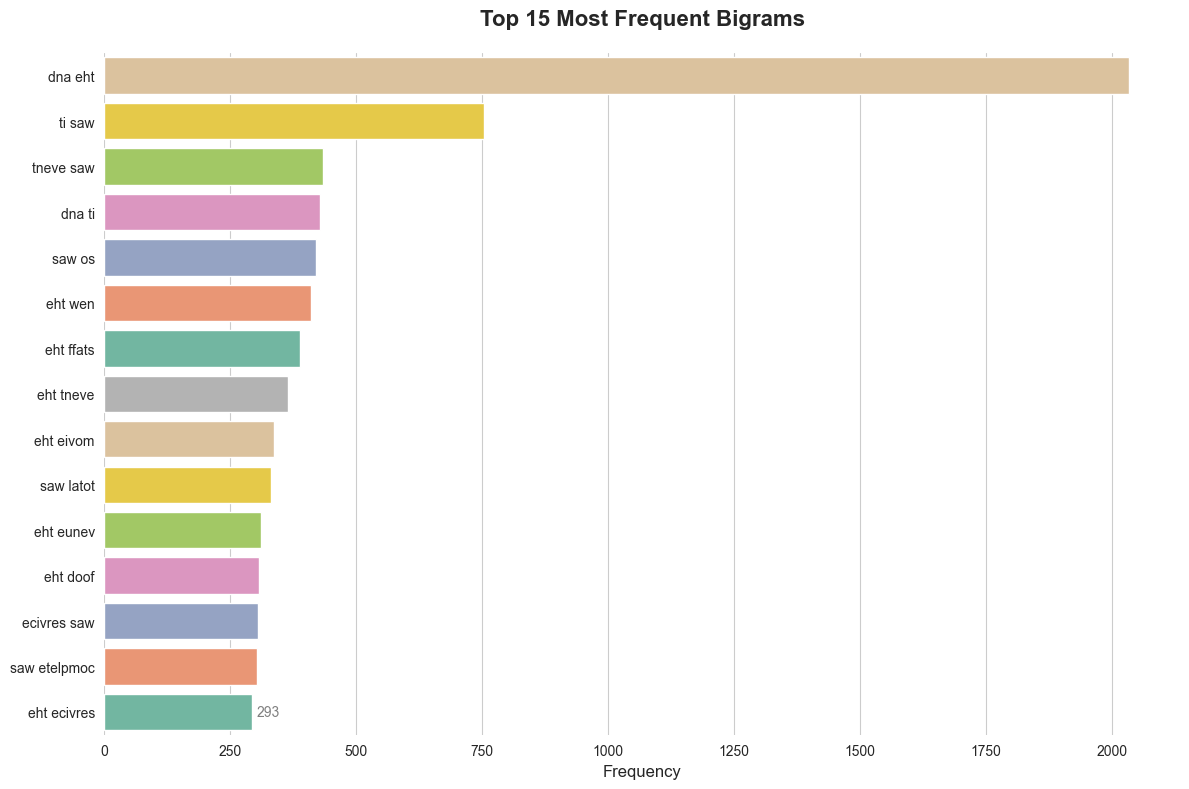

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
def get_top_ngrams(corpus, n=2, top_k=10):
    """
    Optimized n-gram extractor.
    Uses min_df to ignore extremely rare typos and better memory handling.
    """
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        min_df=2 # Only include n-grams that appear at least twice
    ).fit(corpus)

    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Efficiently mapping vocabulary to sums
    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# --- 1. Data Preparation ---
top_bigrams = get_top_ngrams(df['review'], n=2, top_k=15)
ngram_df = pd.DataFrame(top_bigrams, columns=['Phrase', 'Count'])

# --- 2. Advanced Plotting ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Use a gradient palette based on the actual values
ax = sns.barplot(
    data=ngram_df,
    x='Count',
    y='Phrase',
    hue='Count',        # Color intensity based on frequency
    palette='Set2',
    legend=False
)

# Add value labels to the end of each bar for clarity
ax.bar_label(ax.containers[0], padding=3, fontsize=10, color='gray')

# Formatting Refinement
plt.title('Top 15 Most Frequent Bigrams', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel(None) # Phrases are self-explanatory
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

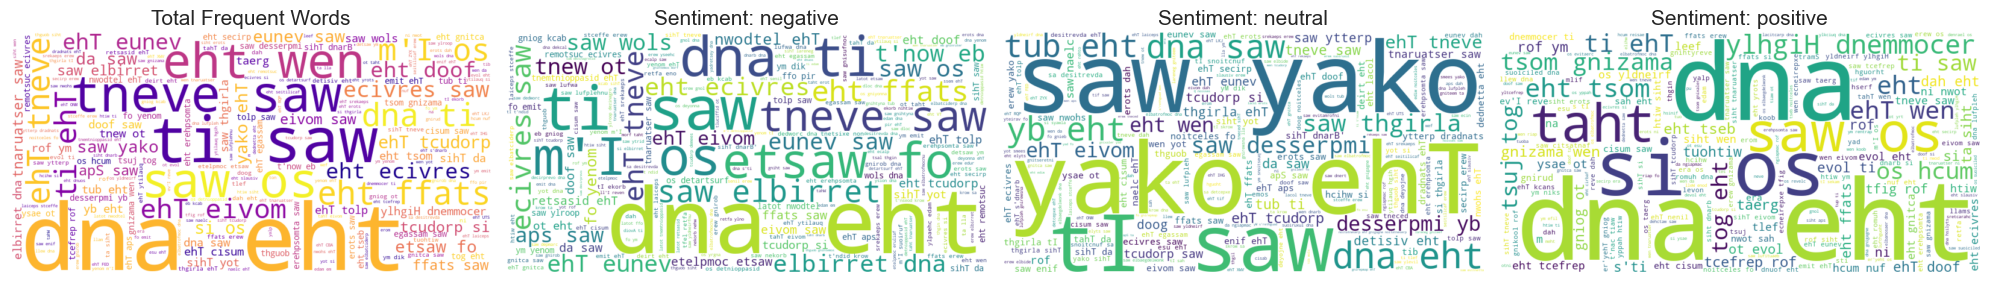

In [8]:
from wordcloud import WordCloud

def plot_wordclouds(df, text_col, sentiment_col):
    # 1. Total Word Cloud
    total_text = " ".join(review for review in df[text_col].astype(str))

    # 2. Split by Sentiment (Assuming labels like 'positive', 'negative')
    sentiments = df[sentiment_col].unique()

    # Setup plotting grid
    fig, axes = plt.subplots(1, len(sentiments) + 1, figsize=(20, 10))

    # Plot Total
    wc_total = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(total_text)
    axes[0].imshow(wc_total, interpolation='bilinear')
    axes[0].set_title('Total Frequent Words', fontsize=15)
    axes[0].axis('off')

    # Plot per Sentiment
    for i, s in enumerate(sentiments):
        s_text = " ".join(review for review in df[df[sentiment_col] == s][text_col].astype(str))
        wc_s = WordCloud(width=800, height=400, background_color='white').generate(s_text)

        axes[i+1].imshow(wc_s, interpolation='bilinear')
        axes[i+1].set_title(f'Sentiment: {s}', fontsize=15)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Execute
plot_wordclouds(df, 'review', 'sentiment')